# 04 — Retention Decisioning

This notebook turns the calibrated CatBoost risk scores from notebook 03 into a **targeting decision**. Two framings are covered:

1. **Campaign economics** — given explicit, labeled assumptions about contact cost, customer value, and retention success rate, an **analytically-derived** break-even probability threshold decides who gets contacted. How does that threshold move as the assumptions move?
2. **Budget-constrained targeting** — if the retention team can only contact N% of customers, whom should it contact, and how much better is that than contacting people at random?

**What this is not:** the dataset has no randomized retention treatment, so there is no observed "success rate" or "uplift" to estimate. Every dollar figure below is a **scenario assumption**, not a measured effect, and every result is a **scenario/expected value**, not a realized or causal campaign outcome. The threshold is derived **analytically from the stated assumptions** — never by scanning validation or test outcomes for whatever threshold happened to maximize realized net value, and never by maximizing F1.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from src import data, evaluation, economics
from src.features import select_X_y

%matplotlib inline
pd.set_option("display.max_columns", 30)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

val = pd.read_csv(PROCESSED_DIR / "val.csv")
test = pd.read_csv(PROCESSED_DIR / "test.csv")
with open(MODEL_DIR / "feature_columns.txt") as f:
    feature_cols = f.read().splitlines()

cat_final = joblib.load(MODEL_DIR / "catboost_final.pkl")

X_val, y_val = select_X_y(val, feature_cols, data.TARGET)
X_test, y_test = select_X_y(test, feature_cols, data.TARGET)

val_proba = cat_final.predict_proba(X_val[feature_cols])[:, 1]
test_proba = cat_final.predict_proba(X_test[feature_cols])[:, 1]

## 1. The analytical break-even threshold

For a customer with predicted churn probability $p$, contacting them has expected scenario value

$$EV(p) = p \times \text{success\_rate} \times \text{value\_per\_retained} - \text{cost\_per\_contact}$$

which is positive iff

$$p > \frac{\text{cost\_per\_contact}}{\text{success\_rate} \times \text{value\_per\_retained}} =: p^*$$

$p^*$ depends **only on the stated business assumptions** — it is computed once from arithmetic, not by scanning validation or test outcomes for whichever cutoff happened to score best. Contacting every customer with predicted $p \ge p^*$ maximizes total expected value across the population, taking the model's probabilities at face value.

**Base-scenario assumptions** (illustrative placeholders — a real deployment substitutes actual CLV/margin figures):
- Cost per contact: **$25**
- Value of a retained customer: **$600**
- Assumed retention success rate among contacted true churners: **30%**

In [2]:
BASE_COST = 25.0
BASE_VALUE = 600.0
BASE_SUCCESS_RATE = 0.30

breakeven = economics.breakeven_threshold(BASE_COST, BASE_SUCCESS_RATE, BASE_VALUE)
print(f"Analytical break-even threshold: {breakeven:.4f}")
print(f"Policy: {economics.policy_label(breakeven)}")

Analytical break-even threshold: 0.1389
Policy: target p >= threshold


## 2. Diagnostic-only sanity check against a hindsight scan (validation)

**This is a diagnostic, not the policy.** For a sanity check only, we scan validation *outcomes* for whatever threshold would have maximized realized net value in hindsight, and plot it next to the analytical $p^*$. If they land far apart, that would suggest the model's probabilities are miscalibrated relative to the stated economics; if they are close, that corroborates that the calibrated probabilities are reasonable inputs to the formula above. **The hindsight-scanned threshold is never used as the business decision** — using it that way is exactly the "threshold chosen by scanning outcomes" mistake this project avoids, for the same reason the max-F1 threshold below is kept as a diagnostic only.

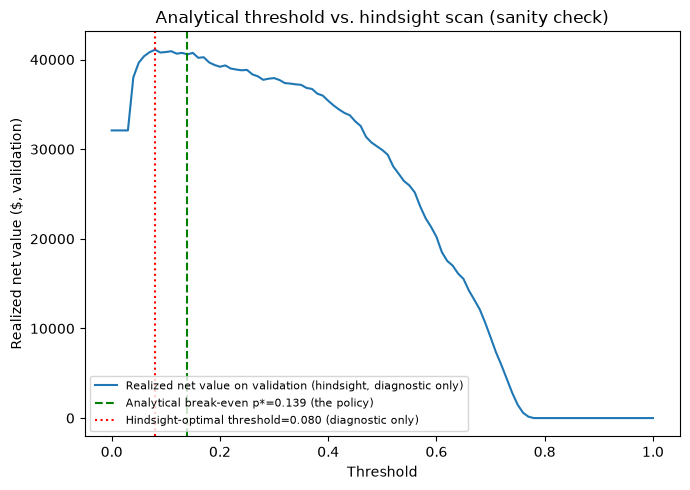

Analytical p* = 0.1389 | Hindsight-scanned optimum (diagnostic only) = 0.0800


In [3]:
thresholds = np.round(np.linspace(0.0, 1.0, 101), 3)
diagnostic_sweep = economics.threshold_sweep_diagnostic(
    y_val, val_proba, thresholds, BASE_COST, BASE_VALUE, BASE_SUCCESS_RATE
)
hindsight_best_row = diagnostic_sweep.loc[diagnostic_sweep["net_value"].idxmax()]
hindsight_threshold = hindsight_best_row["threshold"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(diagnostic_sweep["threshold"], diagnostic_sweep["net_value"], label="Realized net value on validation (hindsight, diagnostic only)")
ax.axvline(breakeven, color="green", linestyle="--", label=f"Analytical break-even p*={breakeven:.3f} (the policy)")
ax.axvline(hindsight_threshold, color="red", linestyle=":", label=f"Hindsight-optimal threshold={hindsight_threshold:.3f} (diagnostic only)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Realized net value ($, validation)")
ax.set_title("Analytical threshold vs. hindsight scan (sanity check)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "economics_analytical_vs_hindsight.png", dpi=150)
plt.show()

print(f"Analytical p* = {breakeven:.4f} | Hindsight-scanned optimum (diagnostic only) = {hindsight_threshold:.4f}")

**Contrast with max-F1 thresholding.** Also shown for reference only — this is explicitly *not* how we choose the business threshold.

In [4]:
from sklearn.metrics import f1_score

f1_scores = [f1_score(y_val, (val_proba >= t).astype(int), zero_division=0) for t in thresholds]
max_f1_threshold = thresholds[int(np.argmax(f1_scores))]
print(f"Max-F1 threshold (validation, diagnostic only): {max_f1_threshold:.3f} (F1={max(f1_scores):.3f})")
print(f"Analytical economics threshold (the actual policy): {breakeven:.3f}")

Max-F1 threshold (validation, diagnostic only): 0.390 (F1=0.641)
Analytical economics threshold (the actual policy): 0.139


## 3. Applying the analytical policy to test (final reporting)

In [5]:
test_economics = economics.apply_analytical_policy(
    y_test, test_proba, BASE_COST, BASE_VALUE, BASE_SUCCESS_RATE
)
pd.Series(test_economics).to_csv(TABLE_DIR / "economics_test_at_analytical_threshold.csv")
test_economics

{'threshold': 0.1388888888888889,
 'policy': 'target p >= threshold',
 'cost_per_contact': 25.0,
 'value_per_retained': 600.0,
 'success_rate': 0.3,
 'n_contacted': 752,
 'pct_contacted': 53.371185237757274,
 'true_churners_reached': 333,
 'expected_retained': 99.89999999999999,
 'cost': 18800.0,
 'expected_value_preserved': 59939.99999999999,
 'net_value': 41139.99999999999,
 'roi': 2.188297872340425}

**These are scenario / expected figures under the stated assumptions, evaluated once on held-out test data — not observed or causal campaign outcomes.** No retention campaign was actually run; `expected_retained`, `expected_value_preserved`, and `net_value` are what the stated assumptions imply *if* the model's probabilities and the assumed 30% success rate both hold.

## 4. Sensitivity analysis: how the analytical threshold moves with the assumptions

In [6]:
sensitivity = economics.analytical_sensitivity_grid(
    y_val, val_proba,
    cost_values=[10, 25, 50, 100],
    success_rate_values=[0.15, 0.30, 0.50],
    value_values=[300, 600, 1000],
)
sensitivity.to_csv(TABLE_DIR / "economics_sensitivity_grid.csv", index=False)
sensitivity.sort_values(["cost_per_contact", "success_rate", "value_per_retained"])

,cost_per_contact,success_rate,value_per_retained,breakeven_threshold,policy,n_contacted,pct_contacted,net_value,roi
0,10,0.15,300,0.222222,target p >= threshold,635,45.067424,7375.0,1.161417
1,10,0.15,600,0.111111,target p >= threshold,813,57.700497,22560.0,2.774908
2,10,0.15,1000,0.066667,target p >= threshold,963,68.346345,44520.0,4.623053
3,10,0.30,300,0.111111,target p >= threshold,813,57.700497,22560.0,2.774908
4,10,0.30,600,0.055556,target p >= threshold,1010,71.682044,55420.0,5.487129
5,10,0.30,1000,0.033333,target p >= threshold,1363,96.735273,98570.0,7.231842
6,10,0.50,300,0.066667,target p >= threshold,963,68.346345,44520.0,4.623053
7,10,0.50,600,0.033333,target p >= threshold,1363,96.735273,98570.0,7.231842
8,10,0.50,1000,0.020000,target p >= threshold,1409,100.000000,172910.0,12.271824
9,25,0.15,300,0.555556,target p >= threshold,261,18.523776,1575.0,0.241379


**Reading the sensitivity grid.** Because the threshold is now a direct function of the three assumptions ($p^* = cost / (success \times value)$), its movement is fully explainable rather than an empirical artifact of a scan: doubling the cost doubles $p^*$; doubling the value or success rate halves it. At the extremes:

- **Cheap, high-conviction scenario** (cost $10, success 50%, value $1,000): $p^* = 0.02$ — contact almost everyone whose risk clears a very low bar.
- **Expensive, low-conviction scenario** (cost $100, success 15%, value $300): $p^* = 2.22 > 1$ — **no customer's probability can clear this bar**, so the rational policy is to run no campaign at all under these assumptions. This is a conclusion the economics model surfaces directly from the formula, not something a purely statistical threshold choice would ever reveal.

There is no single "correct" threshold independent of these business inputs — that is the entire point of exposing the formula rather than hard-coding one number.

## 5. "If we can only contact N% of customers, whom should we contact?" (test set)

A separate decision framework from the analytical threshold above: here, outreach **capacity** (not a per-contact economic bar) is the binding constraint, so we rank-order by risk instead of thresholding.

In [7]:
policy_comparison = economics.targeting_policy_comparison(y_test, test_proba, k_fractions=(0.05, 0.10, 0.20))
policy_comparison.to_csv(TABLE_DIR / "targeting_policy_comparison_test.csv", index=False)
policy_comparison

,top_k_pct,n_contacted,model_churners_captured,model_recall,random_churners_captured_expected,random_recall,lift_vs_random
0,5.0,70,60,0.160428,18.7,0.05,3.208556
1,10.0,141,111,0.296791,37.4,0.10,2.967914
2,20.0,282,194,0.518717,74.8,0.20,2.593583
3,100.0,1409,374,1.000000,374.0,1.00,1.000000


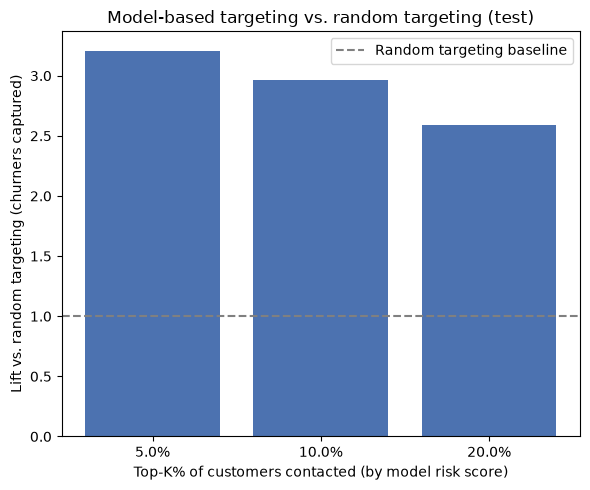

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_df = policy_comparison[policy_comparison["top_k_pct"] < 100]
ax.bar(plot_df["top_k_pct"].astype(str) + "%", plot_df["lift_vs_random"], color="#4C72B0")
ax.axhline(1.0, color="grey", linestyle="--", label="Random targeting baseline")
ax.set_ylabel("Lift vs. random targeting (churners captured)")
ax.set_xlabel("Top-K% of customers contacted (by model risk score)")
ax.set_title("Model-based targeting vs. random targeting (test)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "targeting_lift_vs_random.png", dpi=150)
plt.show()

Model-based targeting captures 2.5x-3.2x as many churners as random targeting of the same size, across every capacity level tested. This is the headline, assumption-free result of the project: **regardless of exactly how the economics are priced, risk-based targeting is a large, robust improvement over random or blanket outreach.**

## 6. Final product recommendation

- **Model to use:** CatBoost, with probability calibration fit by cross-validation on train only (notebook 02). It is close to Logistic Regression on ROC-AUC but clearly ahead on PR-AUC, Brier score/log loss, and every Top-K ranking metric (notebook 03) — the metrics that actually matter for a minority-class targeting problem — so the added complexity is justified, not assumed.
- **Ranking quality:** Top 10% of customers by predicted risk captures ~30% of all churners at ~3x lift over random targeting; this holds up on the held-out test set, not just validation.
- **Calibration:** cross-validated calibration (fit on train only) reduces the test Brier score meaningfully; probabilities are usable as inputs to the economics model, though they should be re-validated whenever the model is retrained or the customer base shifts materially.
- **Targeting policy:** use the analytical break-even threshold $p^* = cost / (success \times value)$ with the business's real assumptions plugged in — not a single hardcoded number, and not a threshold tuned to any observed outcome. Where outreach capacity is fixed instead of a per-contact economic bar, a Top-10% to Top-20% risk-ranked target list is a robust, assumption-light alternative that consistently beats random targeting by ~2.5-3x.
- **Sensitivity:** the break-even threshold is a direct, fully-explainable function of cost, value, and success rate — cheap, high-conviction campaigns should target broadly; expensive or lower-confidence campaigns should target narrowly or, in some plausible scenarios, not run at all. This sensitivity is a feature to communicate to stakeholders, not a weakness to hide.
- **Segments to investigate:** month-to-month, low-tenure, fiber-optic, electronic-check customers concentrate both churn risk and the campaign's targeted population. The long-contract segments deserve a second look, but with the important nuance from notebook 03: one-year-contract recall is far from zero once the analytical threshold (not the arbitrary 0.5 default) is used, and the remaining two-year-contract gap rests on only 9 churners in the test set — too small to call a settled structural finding.
- **What cannot be concluded from this dataset:** any causal claim that contacting a customer would actually prevent their churn, or what the true retention success rate would be. This is an observational, single-snapshot dataset with no randomized intervention.
- **What to test next, experimentally:** see the A/B test design below.

## 7. A/B test design for a real retention intervention

This design is proposed for the business to run; **no result is reported or implied here** — the dataset used in this project cannot supply one.

- **Unit of randomization:** individual customer (not household/account-group, to avoid interference between related accounts on the same contract).
- **Eligible population:** customers above a pre-registered risk-score threshold (e.g., the Top 20% by CatBoost score), to concentrate the test where the intervention is most likely to matter and to keep the sample size for the primary metric feasible given the churn base rate.
- **Control:** no proactive retention contact (standard experience).
- **Treatment:** proactive retention contact (e.g., a support/loyalty call plus a contract or bundled-service offer, informed by the actionable levers identified in notebook 03 — contract terms, security/support add-ons, payment method).
- **Primary metric:** 60-day (or one full billing-cycle-appropriate horizon) churn rate, treatment vs. control, tested with a standard two-proportion test; report absolute and relative risk reduction with a confidence interval, not just a p-value.
- **Guardrails:** cost per contact vs. budget; complaint/opt-out rate; short-term revenue impact of any discount offered (avoid a "win" that is actually a margin giveaway to customers who would not have churned anyway); support-team handling capacity.
- **Major validity risks:**
  - **Contamination/spillover** — treated and control customers may discuss offers (e.g., via review sites, word of mouth, shared households), diluting the measured effect.
  - **Novelty/Hawthorne effects** — a one-off proactive contact may change behavior temporarily regardless of the specific offer content.
  - **Selection into the eligible population** — since eligibility is itself risk-score-based, results generalize to "high-risk customers as scored by this model," not to the full customer base; recalibrate the model periodically so this population doesn't drift.
  - **Underpowered subgroups** — notebook 03 shows very few churners in the one-/two-year contract segments (36 and 9 in this test set), so an A/B test gated on the risk score will have very little power to detect an effect there; a separate, deliberately-oversampled test arm would be needed to learn anything in those segments.
  - **Seasonality** — churn and promotional responsiveness can be seasonal; run the test across a full relevant cycle, not a short window that happens to coincide with unrelated promotions or price changes.